In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import itertools

In [2]:
DATASET_PATH = r"C:\Users\Saagi\Desktop\ANN Datasets\DATASET"
SR = 22050 # sample rate
DURATION = 30.0 # seconds per clip (you chose 30s)
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
MAX_PAD_LEN = int(np.ceil((DURATION * SR) / HOP_LENGTH))
FEATURES_FILE = 'X.npy'
LABELS_FILE = 'y.npy'

In [5]:
def extract_mel_spectrogram(file_path, sr=SR, duration=DURATION, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, max_pad_len=MAX_PAD_LEN):
    try:
        audio, sr = librosa.load(file_path, sr=sr, duration=duration, res_type='kaiser_fast')
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)


# pad or truncate
        if mel_spec_db.shape[1] < max_pad_len:
           pad_width = max_pad_len - mel_spec_db.shape[1]
           mel_spec_db = np.pad(mel_spec_db, pad_width=((0,0),(0,pad_width)), mode='constant')
        else:
           mel_spec_db = mel_spec_db[:, :max_pad_len]


        return mel_spec_db
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [6]:
if os.path.exists(FEATURES_FILE) and os.path.exists(LABELS_FILE):
    print("Loading saved features...")
    X = np.load(FEATURES_FILE)
    y = np.load(LABELS_FILE)
else:
    print("Extracting features from audio files. This may take a while...")
    X = []
    y = []


    genres = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
    print(f"Found genres: {genres}")


    for genre in genres:
        genre_path = os.path.join(DATASET_PATH, genre)
        files = [f for f in os.listdir(genre_path) if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))]
        print(f"Processing {len(files)} files in genre '{genre}'")


        for file in files:
            file_path = os.path.join(genre_path, file)
            mel = extract_mel_spectrogram(file_path)
            if mel is not None:
                X.append(mel)
                y.append(genre)


    X = np.array(X)
    y = np.array(y)


    # Save for faster reuse
    np.save(FEATURES_FILE, X)
    np.save(LABELS_FILE, y)
    print(f"Saved features to {FEATURES_FILE} and labels to {LABELS_FILE}")


print("Feature array shape:", X.shape)
print("Labels shape:", y.shape)

Extracting features from audio files. This may take a while...
Found genres: ['melody', 'rap']
Processing 20 files in genre 'melody'
Processing 21 files in genre 'rap'
Saved features to X.npy and labels to y.npy
Feature array shape: (41, 128, 1292)
Labels shape: (41,)


In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
# Add channel dimension for CNN: (samples, n_mels, time_steps, 1)
X = X[..., np.newaxis]


# Normalize X to range 0-1
X_min = X.min()
X_max = X.max()
X = (X - X_min) / (X_max - X_min + 1e-9)


X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)


print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (32, 128, 1292, 1) Test shape: (9, 128, 1292, 1)


In [8]:
input_shape = X_train.shape[1:]
num_classes = y_onehot.shape[1]


def build_model(input_shape, num_classes):
    model = Sequential()


    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.2))


    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.2))


    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))


    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation='softmax'))


    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model = build_model(input_shape, num_classes)
model.summary()

C:\Users\Saagi\.conda\envs\GreeshuDL\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 1292, 32)       │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 1292, 32)       │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 646, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 646, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 646, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 646, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 323, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 323, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 323, 128)        │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 323, 128)        │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 161, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 161, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 329728)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      84,410,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 84,504,706 (322.36 MB)

 Trainable params: 84,504,258 (322.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)


EPOCHS = 30
BATCH_SIZE = 16


history = model.fit(
X_train, y_train,
validation_split=0.2,
epochs=EPOCHS,
batch_size=BATCH_SIZE,
callbacks=[checkpoint, reduce_lr]
)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.5525 - loss: 74.8898

2/2 ━━━━━━━━━━━━━━━━━━━━ 153s 95s/step - accuracy: 0.4800 - loss: 148.7736 - val_accuracy: 0.5714 - val_loss: 3.0917 - learning_rate: 0.0010
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 133s 48s/step - accuracy: 0.4800 - loss: 281.8236 - val_accuracy: 0.5714 - val_loss: 1.7510 - learning_rate: 0.0010
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 58s 27s/step - accuracy: 0.8000 - loss: 40.0637 - val_accuracy: 0.5714 - val_loss: 1.1749 - learning_rate: 0.0010
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7550 - loss: 85.2480 

2/2 ━━━━━━━━━━━━━━━━━━━━ 102s 58s/step - accuracy: 0.7600 - loss: 78.9053 - val_accuracy: 0.7143 - val_loss: 0.5136 - learning_rate: 0.0010
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 9s/step - accuracy: 0.7600 - loss: 35.5757 - val_accuracy: 0.4286 - val_loss: 1.3075 - learning_rate: 0.0010
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 8s/step - accuracy: 0.8800 - loss: 16.1728 - val_accuracy: 0.4286 - val_loss: 6.1999 - learning_rate: 0.0010
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8775 - loss: 3.8999  
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.8800 - loss: 4.8802 - val_accuracy: 0.4286 - val_loss: 11.7547 - learning_rate: 0.0010
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 10s/step - accuracy: 0.8000 - loss: 27.5220 - val_accuracy: 0.4286 - val_loss: 12.8977 - learning_rate: 5.0000e-04
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.9600 - loss: 5.9408 - val_accuracy: 0.4286 - val

2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 25s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.8571 - val_loss: 0.8646 - learning_rate: 3.9063e-06


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4444 - loss: 2.2809
Test accuracy: 0.4444, Test loss: 2.2809
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


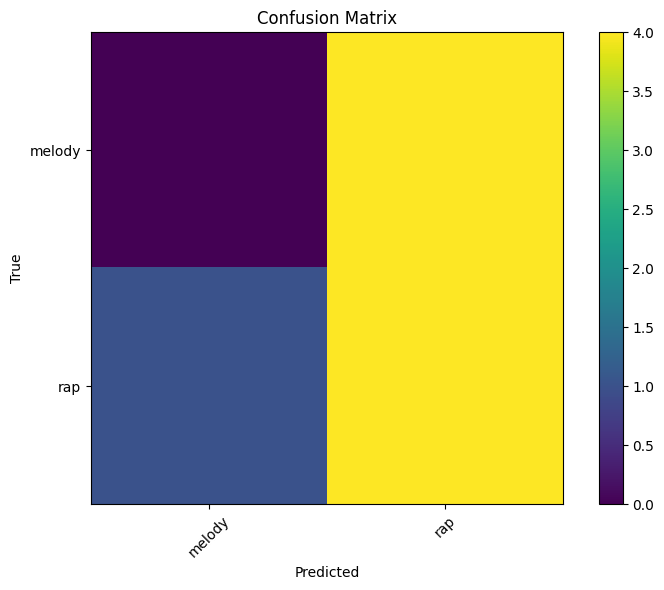


Classification Report:

              precision    recall  f1-score   support

      melody       0.00      0.00      0.00         4
         rap       0.50      0.80      0.62         5

    accuracy                           0.44         9
   macro avg       0.25      0.40      0.31         9
weighted avg       0.28      0.44      0.34         9



In [10]:
from tensorflow.keras.models import load_model
best = load_model('best_model.h5')


test_loss, test_acc = best.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


# Predictions and confusion matrix
y_pred_probs = best.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = np.argmax(y_test, axis=1)


cm = confusion_matrix(y_true, y_pred)


# Plot confusion matrix
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
labels = le.classes_
plt.xticks(np.arange(len(labels)), labels, rotation=45)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=le.classes_))

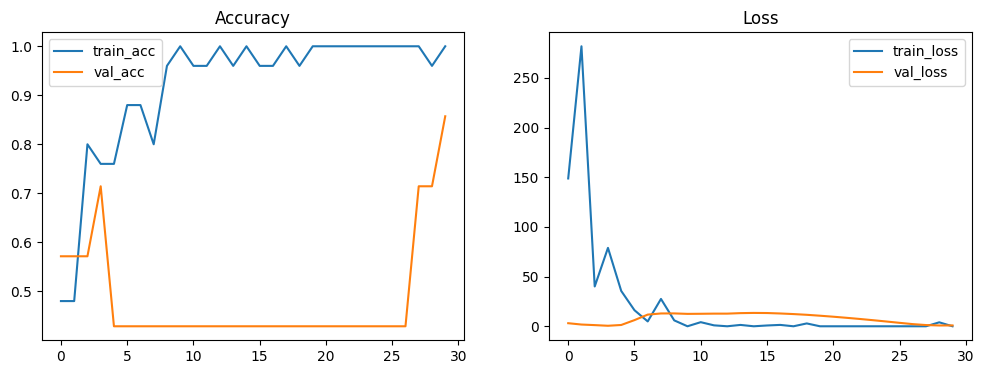

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()

In [14]:
example_file = r"E:\Songs\Naan_Aval_Illai-StarMusiQ.Com.mp3"
# example_file = r"C:\path\to\some\song.mp3"


if example_file:
    mel = extract_mel_spectrogram(example_file)
    mel = mel[np.newaxis, ..., np.newaxis]
    mel = (mel - X_min) / (X_max - X_min + 1e-9)
    pred = best.predict(mel)
    print("Predicted:", le.classes_[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predicted: melody


In [15]:
example_file = r"E:\Songs\Thalli Pogathey.mp3"
# example_file = r"C:\path\to\some\song.mp3"


if example_file:
    mel = extract_mel_spectrogram(example_file)
    mel = mel[np.newaxis, ..., np.newaxis]
    mel = (mel - X_min) / (X_max - X_min + 1e-9)
    pred = best.predict(mel)
    print("Predicted:", le.classes_[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Predicted: melody


In [16]:
example_file = r"E:\Songs\Tamil Songs\Kabali [2016] [Itunes Mp3 - 320Kbps] - Santhosh Narayanan Musical\01 Ulagam Oruvanukka.mp3"
# example_file = r"C:\path\to\some\song.mp3"


if example_file:
    mel = extract_mel_spectrogram(example_file)
    mel = mel[np.newaxis, ..., np.newaxis]
    mel = (mel - X_min) / (X_max - X_min + 1e-9)
    pred = best.predict(mel)
    print("Predicted:", le.classes_[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Predicted: rap
